In [1]:
# Execution environment: Python 3.12 
# Tested CNN model : Resnet50

import os
import random
import numpy as np
import tensorflow as tf

import general_TFRP_v1 as TFRP
import matplotlib.pyplot as plt

from tensorflow.keras.applications.resnet50 import preprocess_input,decode_predictions
from tensorflow.keras.preprocessing import image


In [2]:
#######################################################################
# load orig. images and rel maps
#######################################################################
## Load model ###########################################################
from keras.models import load_model
from tensorflow.keras.applications import ResNet50

model = ResNet50(weights='imagenet', )

img_width, img_height = (224, 224)
img_shape = (img_width, img_height, 3)

############
model_type = "resnet50"
############


def set_seeds(seed=42):
    # 1. Fix  Python &Hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    
    # 2. Fix NumPy seed
    np.random.seed(seed)
    
    # 3. Fix TensorFlow seed
    tf.random.set_seed(seed)
    
    # 4. Forcing determinism in TensorFlow operations
    # “Ensuring bitwise reproducibility by fixing the execution order of operations in TensorFlow 2.9 and later”
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    
    # For newer TensorFlow versions, the following command may also be useful.
    # tf.config.experimental.enable_op_determinism()

set_seeds(42)


In [3]:
# Load test image ########################
image_name = 'imagen_5/n01443537_goldfish.JPEG'

org_imgs = np.zeros((1, img_width, img_height, 3))   # for original image
input_imgs = np.zeros((1, img_width, img_height, 3)) # for preprocessed image

img = image.load_img(image_name, target_size=(img_width, img_height))
x = image.img_to_array(img)
org_imgs[0] = x.copy()
x = preprocess_input(x)
input_imgs[0] = x.copy()

# Perform prediction and take top classes ######################### 
preds = model.predict(input_imgs)
top_classes = np.argmax(preds, axis=1)
top_class_labels = decode_predictions(preds, top=1)
top_class_probs = np.max(preds, axis=1)

print (f"Top class index: {top_classes[0]}, label: {top_class_labels[0][0][1]}, probability: {top_class_probs[0]:.4f}") 


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
Top class index: 1, label: goldfish, probability: 0.9560


In [4]:
# Take TFRP relevance map for the top class #########################

# test Z-plus rule
print("\nTesting Z-plus rule...")
result_1, initial_sum, final_sum, leakage_percent = TFRP.get_relevance_map_generalized(model, input_imgs, target_class_idx=None, 
                    use_logit=True, global_rule='z_plus', composite_preset=None) 
print(f"Initial relevance sum: {initial_sum:.4f}, Final relevance sum: {final_sum:.4f}, Leakage percent: {leakage_percent:.4f}%")   

# test epsilon rule
print("\nTesting epsilon rule...")
result_2, initial_sum, final_sum, leakage_percent = TFRP.get_relevance_map_generalized(model, input_imgs, target_class_idx=None, 
                    use_logit=True, global_rule='epsilon', composite_preset=None) 

print(f"Initial relevance sum: {initial_sum:.4f}, Final relevance sum: {final_sum:.4f}, Leakage percent: {leakage_percent:.4f}%")   

# test alpha-beta rule
print("\nTesting alpha-beta rule...")
result_3, initial_sum, final_sum, leakage_percent = TFRP.get_relevance_map_generalized(model, input_imgs, target_class_idx=None, 
                    use_logit=True, global_rule='alpha_beta', composite_preset=None) 

print(f"Initial relevance sum: {initial_sum:.4f}, Final relevance sum: {final_sum:.4f}, Leakage percent: {leakage_percent:.4f}%")   

# test composite rule
print("\nTesting composite rule...")
composite_preset = {'Conv2D': 'alpha_beta', 'Dense': 'epsilon'}
result_4, initial_sum, final_sum, leakage_percent = TFRP.get_relevance_map_generalized(model, input_imgs, target_class_idx=None, 
                    use_logit=True, global_rule='composite', composite_preset=composite_preset) 

print(f"Initial relevance sum: {initial_sum:.4f}, Final relevance sum: {final_sum:.4f}, Leakage percent: {leakage_percent:.4f}%")   




Testing Z-plus rule...
---------------------------------------------------------------------------
Initial Prediction Sum: 19.331913
Final Relevance Sum:    19.331905
Total Network Leakage:  0.000039%
Initial relevance sum: 19.3319, Final relevance sum: 19.3319, Leakage percent: 0.0000%

Testing epsilon rule...
---------------------------------------------------------------------------
Initial Prediction Sum: 19.331913
Final Relevance Sum:    -0.008368
Total Network Leakage:  100.043282%
Initial relevance sum: 19.3319, Final relevance sum: -0.0084, Leakage percent: 100.0433%

Testing alpha-beta rule...
---------------------------------------------------------------------------
Initial Prediction Sum: 19.331913
Final Relevance Sum:    19.331791
Total Network Leakage:  0.000631%
Initial relevance sum: 19.3319, Final relevance sum: 19.3318, Leakage percent: 0.0006%

Testing composite rule...
---------------------------------------------------------------------------
Initial Prediction Su

In [11]:
# Visualize TFRP relevance maps

def visualize_TFRP_relevance_map(model, org_img, input_img, relevance_map, top_class_idx, grad_th=0.2,
                       alpha=0.5, sigma=1, segment_n=400, step=3, title="TFRP Relevance Map"):

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))

    rel_map, overlay = TFRP.visualize_TFRP_new(model,org_img, input_img, relevance_map, top_class_idx, grad_th=grad_th,
                        alpha=alpha, sigma=sigma, segment_n=segment_n, step=step)


    axes[0].imshow(org_imgs[0]/255.0)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(rel_map)
    axes[1].set_title("TFRP Relevance Map")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("TFRP Relevance Map with Overlay")
    axes[2].axis("off")

    # 레이아웃 자동 조정
    fig.suptitle(title)   
    plt.tight_layout()
    plt.show()




Original Image Size: 224x224


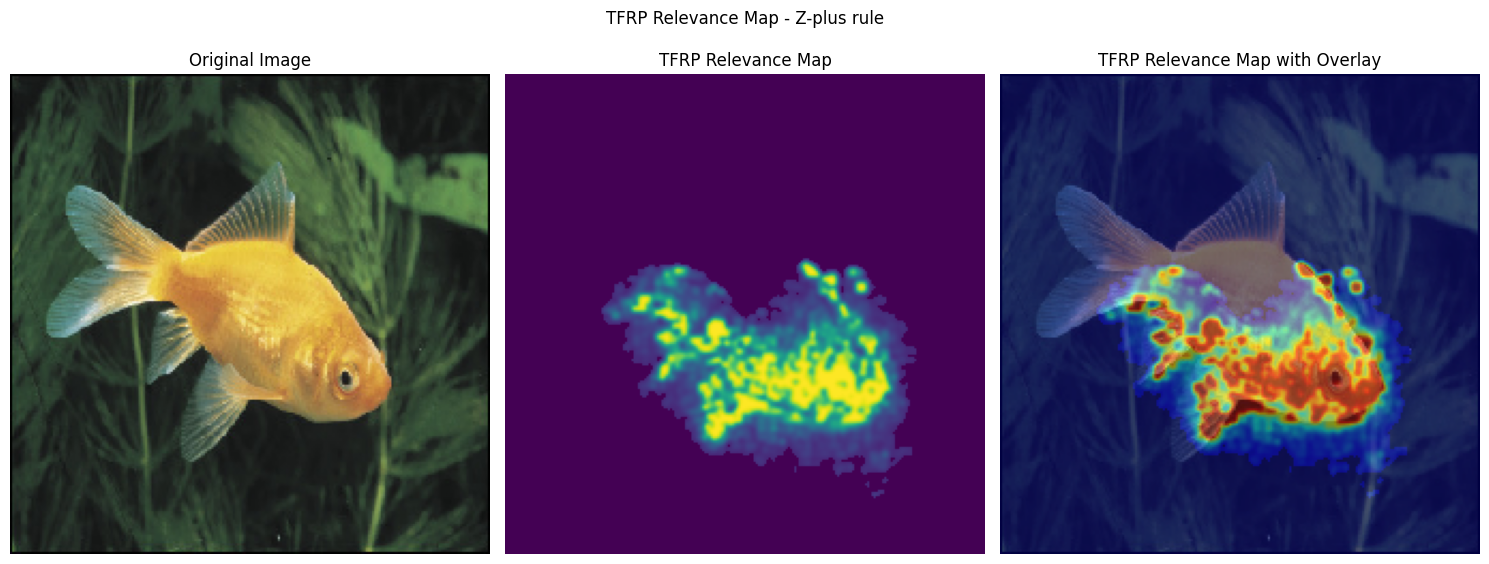

In [12]:
visualize_TFRP_relevance_map(model, org_imgs[0], input_imgs[0], result_1[0], top_classes[0], title="TFRP Relevance Map - Z-plus rule")  


Original Image Size: 224x224


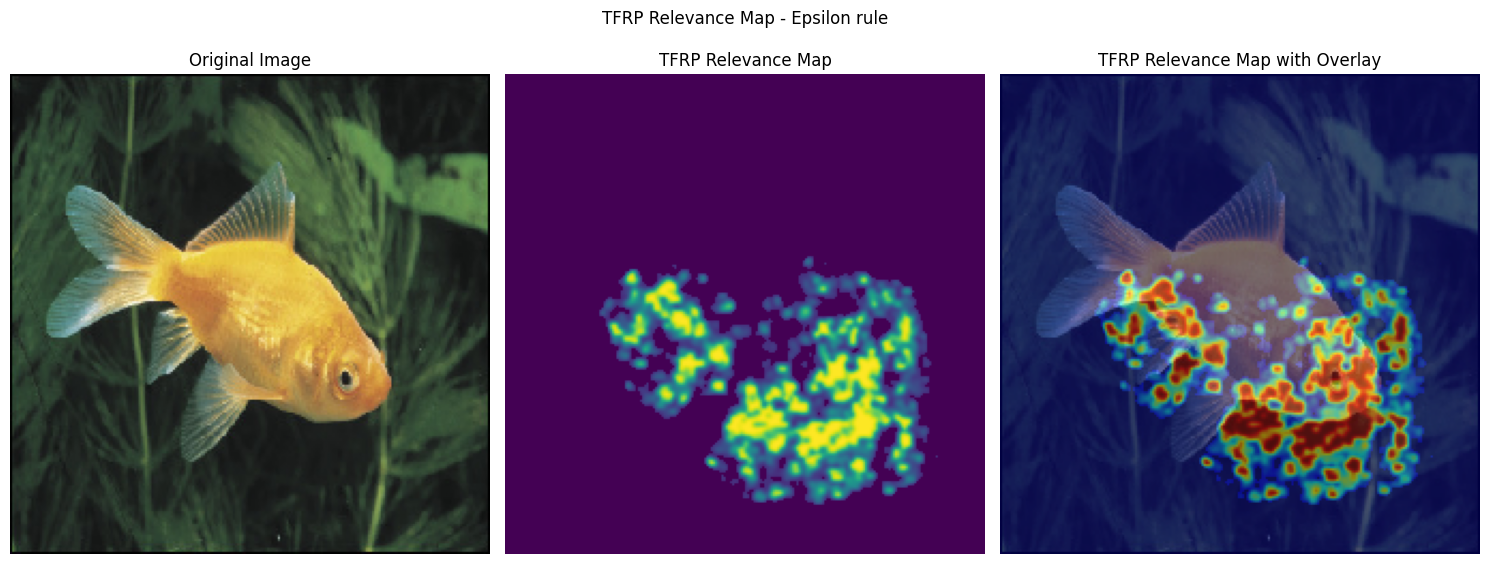

In [13]:
visualize_TFRP_relevance_map(model, org_imgs[0], input_imgs[0], result_2[0], top_classes[0], title="TFRP Relevance Map - Epsilon rule")


Original Image Size: 224x224


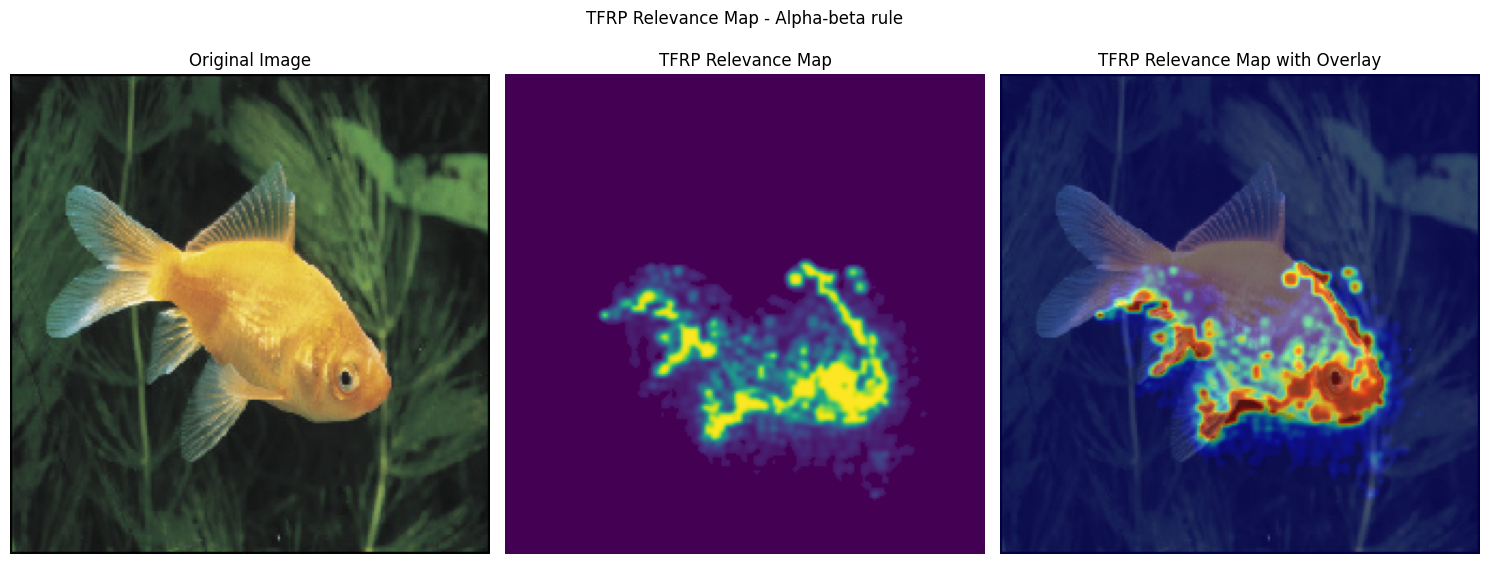

In [16]:
visualize_TFRP_relevance_map(model, org_imgs[0], input_imgs[0], result_3[0], top_classes[0], title="TFRP Relevance Map - Alpha-beta rule")


Original Image Size: 224x224


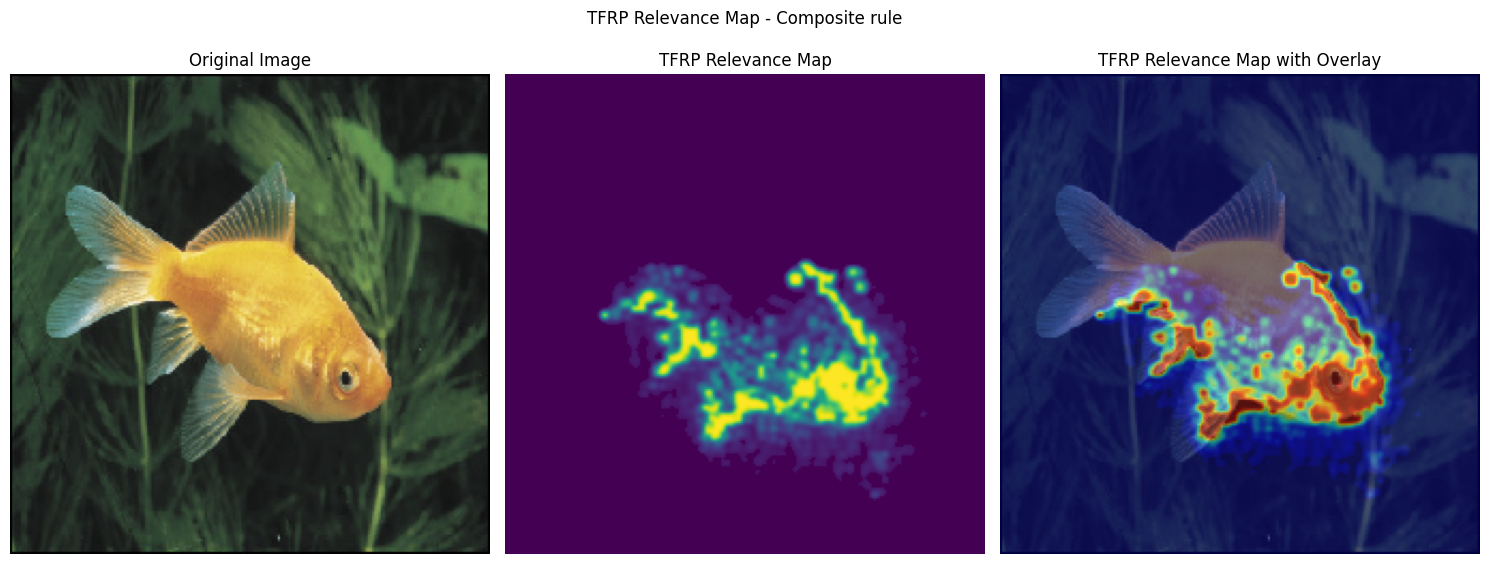

In [17]:
visualize_TFRP_relevance_map(model, org_imgs[0], input_imgs[0], result_4[0], top_classes[0], title="TFRP Relevance Map - Composite rule")